In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("traffic_accident_dataset.csv")
df.head()

,Accident_ID,Date,Time,Location,Weather,Road_Condition,Severity,Vehicle_Type
0,1,2025-01-05,07:30,City Center,Clear,Dry,Low,Car
1,2,2025-01-06,22:15,Highway A,Rain,Wet,High,Bike
2,3,2025-01-07,18:45,Main Road,Fog,Wet,Medium,Car
3,4,2025-01-08,01:20,Highway A,Rain,Wet,Fatal,Truck
4,5,2025-01-10,13:10,City Center,Clear,Dry,Low,Car


In [ ]:
print("Dataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistics:")
print(df.describe())

Dataset Shape:
(20, 8)

Column Names:
Index(['Accident_ID', 'Date', 'Time', 'Location', 'Weather', 'Road_Condition',
       'Severity', 'Vehicle_Type'],
      dtype='object')

Data Types:
Accident_ID        int64
Date              object
Time              object
Location          object
Weather           object
Road_Condition    object
Severity          object
Vehicle_Type      object
dtype: object

Missing Values:
Accident_ID       0
Date              0
Time              0
Location          0
Weather           0
Road_Condition    0
Severity          0
Vehicle_Type      0
dtype: int64

Statistics:
       Accident_ID
count     20.00000
mean      10.50000
std        5.91608
min        1.00000
25%        5.75000
50%       10.50000
75%       15.25000
max       20.00000


In [ ]:
df.drop_duplicates(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time']).dt.time
print("After Cleaning:")
print(df.info())

After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Accident_ID     20 non-null     int64         
 1   Date            20 non-null     datetime64[ns]
 2   Time            20 non-null     object        
 3   Location        20 non-null     object        
 4   Weather         20 non-null     object        
 5   Road_Condition  20 non-null     object        
 6   Severity        20 non-null     object        
 7   Vehicle_Type    20 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 1.4+ KB
None


C:\Users\yacca\AppData\Local\Temp\ipykernel_7784\4087013420.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time


In [ ]:
def get_time_period(time):
    hour = time.hour
    if hour >= 5 and hour < 12:
        return "Morning"
    elif hour >= 12 and hour < 17:
        return "Afternoon"
    elif hour >= 17 and hour < 21:
        return "Evening"
    else:
        return "Night"
df['Time_Period'] = df['Time'].apply(get_time_period)
df.head()

,Accident_ID,Date,Time,Location,Weather,Road_Condition,Severity,Vehicle_Type,Time_Period
0,1,2025-01-05,07:30:00,City Center,Clear,Dry,Low,Car,Morning
1,2,2025-01-06,22:15:00,Highway A,Rain,Wet,High,Bike,Night
2,3,2025-01-07,18:45:00,Main Road,Fog,Wet,Medium,Car,Evening
3,4,2025-01-08,01:20:00,Highway A,Rain,Wet,Fatal,Truck,Night
4,5,2025-01-10,13:10:00,City Center,Clear,Dry,Low,Car,Afternoon


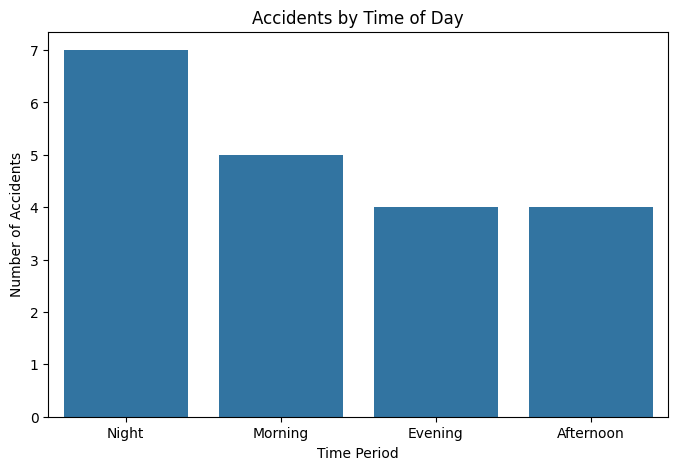

In [ ]:
time_data = df['Time_Period'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=time_data.index, y=time_data.values)
plt.title("Accidents by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Accidents")
plt.show()

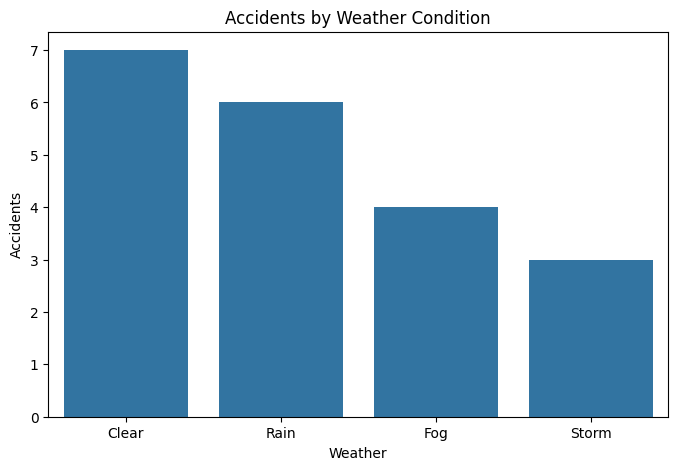

In [ ]:
weather = df['Weather'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=weather.index, y=weather.values)
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Accidents")
plt.show()

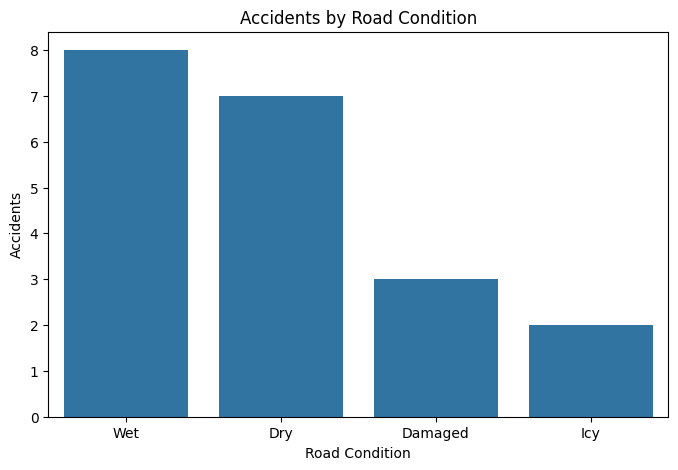

In [ ]:
road = df['Road_Condition'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=road.index, y=road.values)
plt.title("Accidents by Road Condition")
plt.xlabel("Road Condition")
plt.ylabel("Accidents")
plt.show()

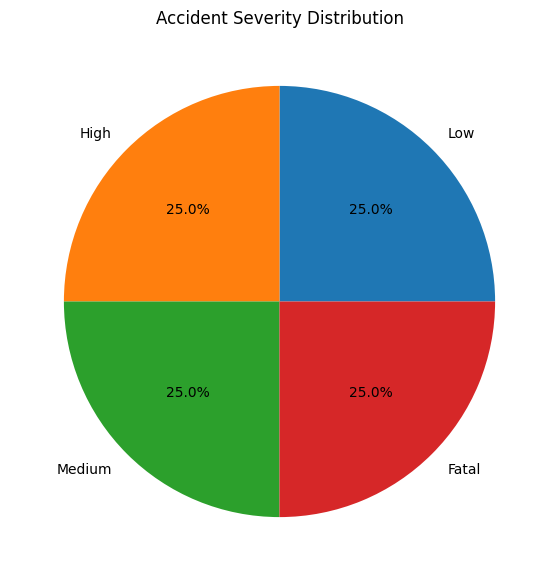

In [ ]:
severity = df['Severity'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    severity.values,
    labels=severity.index,
    autopct='%1.1f%%'
)
plt.title("Accident Severity Distribution")
plt.show()

In [ ]:
hotspots = df['Location'].value_counts()
print("Top Accident Locations:")
print(hotspots)

Top Accident Locations:
Location
Highway A      7
City Center    5
Main Road      4
Market Road    4
Name: count, dtype: int64


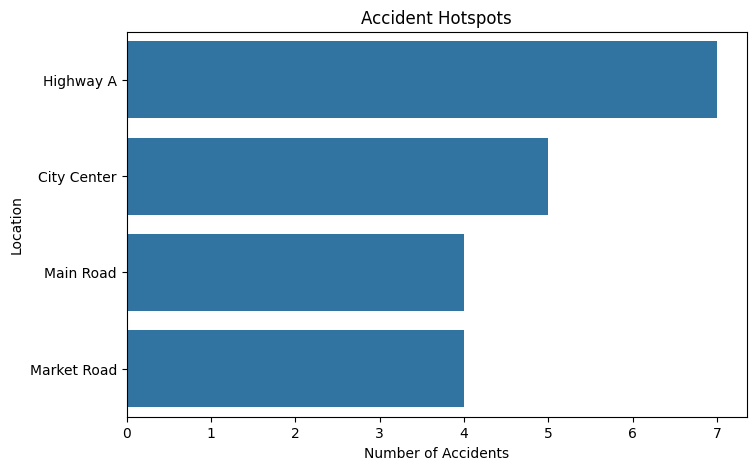

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=hotspots.values,
    y=hotspots.index
)
plt.title("Accident Hotspots")
plt.xlabel("Number of Accidents")
plt.ylabel("Location")
plt.show()

Severity  Fatal  High  Low  Medium
Weather                           
Clear         0     0    5       2
Fog           1     2    0       1
Rain          2     2    0       2
Storm         2     1    0       0


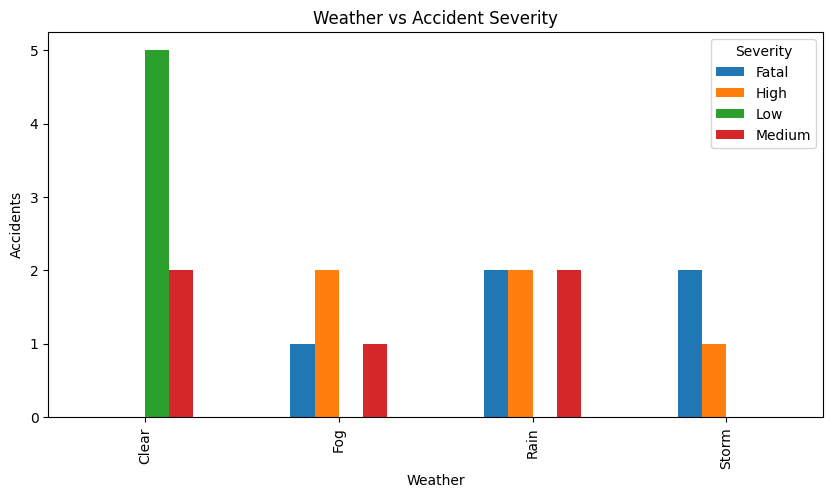

In [ ]:
cross = pd.crosstab(
    df['Weather'],
    df['Severity']
)
print(cross)
cross.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Weather vs Accident Severity")
plt.xlabel("Weather")
plt.ylabel("Accidents")
plt.show()

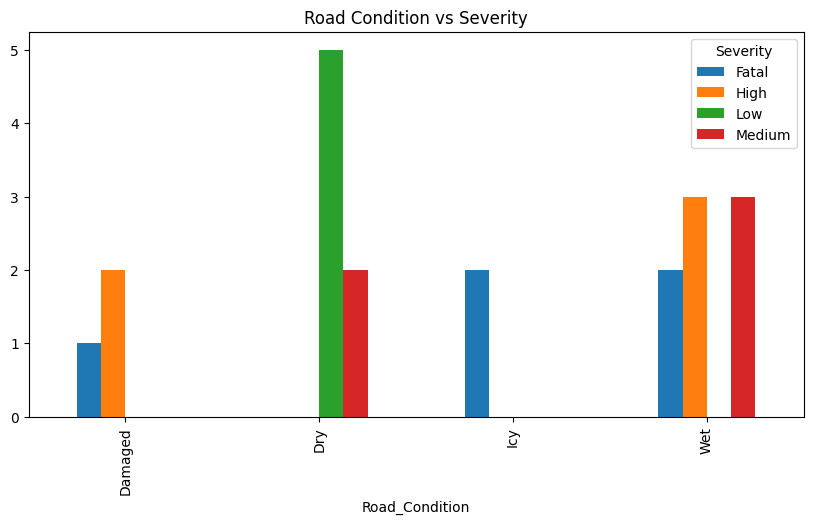

In [ ]:
road_severity = pd.crosstab(
    df['Road_Condition'],
    df['Severity']
)
road_severity.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Road Condition vs Severity")
plt.show()

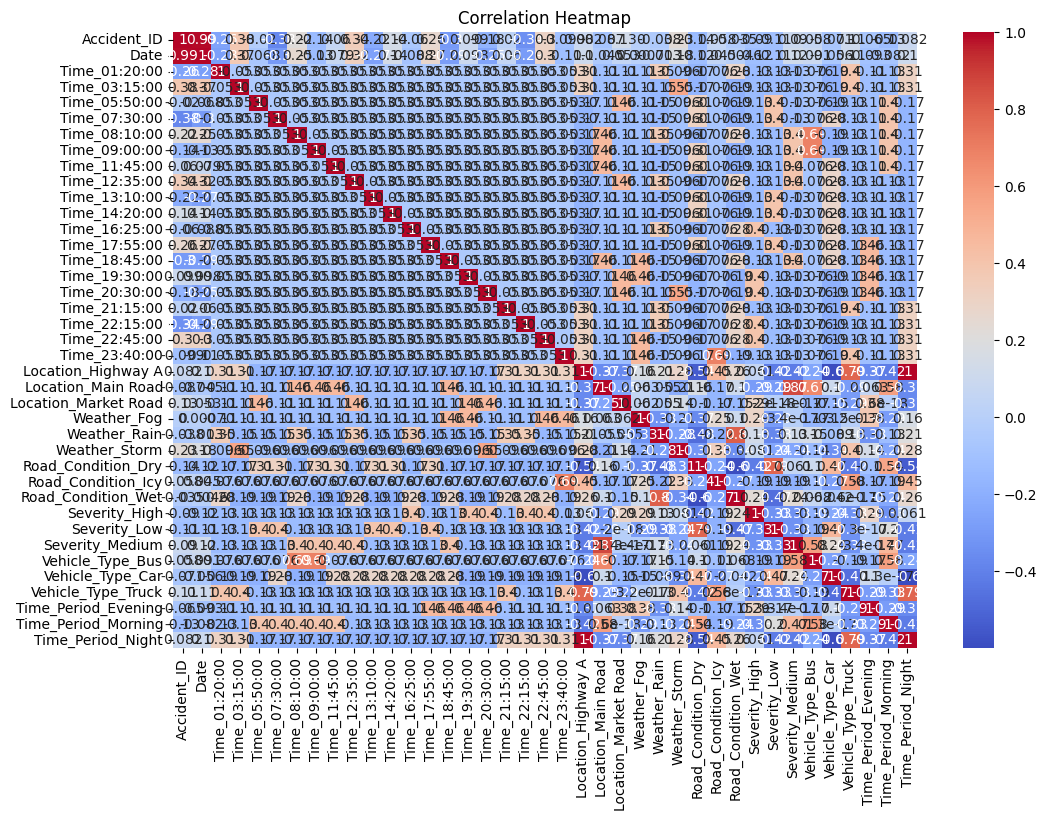

In [ ]:
df_encoded = df.copy()
df_encoded = pd.get_dummies(
    df_encoded,
    drop_first=True
)
plt.figure(figsize=(12,8))
sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Total Accidents:", len(df))
print("\nMost Dangerous Location:")
print(df['Location'].value_counts().idxmax())
print("\nMost Common Weather:")
print(df['Weather'].value_counts().idxmax())
print("\nMost Common Road Condition:")
print(df['Road_Condition'].value_counts().idxmax())
print("\nMost Common Accident Time:")
print(df['Time_Period'].value_counts().idxmax())

Total Accidents: 20

Most Dangerous Location:
Highway A

Most Common Weather:
Clear

Most Common Road Condition:
Wet

Most Common Accident Time:
Night
